# `ExternalPatch` — patchy self-assembly (dimers & filaments)

`hoomd.align_angle.ExternalPatch` gives a particle a **directional sticky patch**
without any orientational degrees of freedom: the patch of an *attractor* `P`
points from `P` toward a partner *director* particle `D`. Two attractors feel an
attraction only when their patches point at each other:

$$U_{ik} = f_i\,f_k\;\epsilon\,(1 - r^2/r_c^2)^2,\qquad
f = 3t^2 - 2t^3,\quad t = \mathrm{clamp}\!\left(\tfrac{\hat p\cdot\hat r - (1-w)}{w},0,1\right),$$

so the patch is active over a cone of half-width set by `width` $w$. The "torque"
that keeps patches facing appears as ordinary forces on the four particles
($P_i, D_i, P_k, D_k$).

**What this demo shows.** The *same* force self-assembles different structures
depending on how many patches each unit carries:

| case | unit | patches | assembles into |
|------|------|---------|----------------|
| **dimers** | `P–D` dipole | 1 (outward) | isolated **pairs** |
| **filaments** | `P–D–P` tripole | 2 (both outward) | **a connected network** |

We run both in a thin slab and read out the assembled structures.

In [1]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

import hoomd
import hoomd.md
import gsd.hoomd

from hoomd import align_angle

import demo_viz as v   # (unused here — assembly is quasi-2D, so we plot in-plane)

try:
    device = hoomd.device.GPU()
except Exception:
    device = hoomd.device.CPU()
print("HOOMD", hoomd.version.version, "| device:", type(device).__name__,
      "| precision", hoomd.version.floating_point_precision)

HOOMD 6.1.1 | device: GPU | precision (64, 32)


## 1. Parameters

In [2]:
N_UNITS  = 600        # dipoles (dimers) or tripoles (filaments); dilute enough to
                      # assemble into DISTINCT structures (denser -> percolates/collapses)
BOND_R0  = 0.5        # P-D tether length
DPD_A    = 40.0       # DPD repulsion between attractors (P-P)
EPSILON  = 30.0       # patch attraction strength
WIDTH    = {"dimers": 0.25, "filaments": 0.3}   # narrow cones -> directional (head-to-tail)
                                                # bonding; wider cones let filaments branch/condense
Lz       = 5.0        # thin-slab thickness (quasi-2D)
kT, DT   = 1.0, 0.005
NSTEPS   = 400_000    # assembly time
SPACING  = 2.0        # initial grid spacing (> CONTACT, so t=0 has no spurious contacts)

OUT_DIR = pathlib.Path("./external_patch_traj"); OUT_DIR.mkdir(exist_ok=True)
gsd_path = lambda label, tag: OUT_DIR / f"{label}_{tag}.gsd"
CONTACT = 1.0         # P-P contact distance for structure analysis

## 2. Build the two unit types

Both live on a jittered grid in a thin slab with random patch orientations. A
**dimer** unit is `P–D` with the patch $P\!\to\!D$; a **filament** unit is
`P_a–D–P_b` with `D` central, so both patches point *outward* (and a stiff angle
keeps the rod straight).

In [3]:
def build_units(kind):
    per = 2 if kind == "dimers" else 3
    N = per * N_UNITS
    side = int(np.ceil(np.sqrt(N_UNITS)))
    L = side * SPACING + 4.0
    rng = np.random.default_rng(42)

    pos = np.zeros((N, 3)); tid = np.zeros(N, dtype=int)
    # random unit vectors (patch/rod axes)
    u = rng.normal(size=(N_UNITS, 3)); u /= np.linalg.norm(u, axis=1, keepdims=True)
    cx = ((np.arange(N_UNITS) % side) - side / 2) * SPACING + rng.uniform(-0.3, 0.3, N_UNITS)
    cy = ((np.arange(N_UNITS) // side) - side / 2) * SPACING + rng.uniform(-0.3, 0.3, N_UNITS)
    cz = rng.uniform(-Lz / 2 + 0.5, Lz / 2 - 0.5, N_UNITS)
    ctr = np.column_stack([cx, cy, cz])

    bonds, partners, angles = [], [], []
    if kind == "dimers":
        iP, iD = 2 * np.arange(N_UNITS), 2 * np.arange(N_UNITS) + 1
        pos[iP] = ctr; pos[iD] = ctr + BOND_R0 * u
        tid[iD] = 1
        bonds = np.column_stack([iP, iD])
        partners = np.column_stack([iP, iD])          # patch P -> D (outward)
    else:
        iPa, iD, iPb = 3 * np.arange(N_UNITS), 3 * np.arange(N_UNITS) + 1, 3 * np.arange(N_UNITS) + 2
        pos[iD] = ctr; pos[iPa] = ctr - BOND_R0 * u; pos[iPb] = ctr + BOND_R0 * u
        tid[iD] = 1
        bonds = np.vstack([np.column_stack([iPa, iD]), np.column_stack([iPb, iD])])
        angles = np.column_stack([iPa, iD, iPb])
        partners = np.vstack([np.column_stack([iPa, iD]),   # both patches outward from centre
                              np.column_stack([iPb, iD])])

    fr = gsd.hoomd.Frame()
    fr.configuration.box = [L, L, Lz, 0, 0, 0]
    fr.particles.N = N; fr.particles.types = ["P", "D"]
    fr.particles.typeid = tid; fr.particles.position = pos; fr.particles.mass = np.ones(N)
    fr.bonds.N = len(bonds); fr.bonds.types = ["PD"]; fr.bonds.typeid = np.zeros(len(bonds), int)
    fr.bonds.group = bonds
    if len(angles):
        fr.angles.N = len(angles); fr.angles.types = ["PDP"]
        fr.angles.typeid = np.zeros(len(angles), int); fr.angles.group = angles
    path = gsd_path(kind, "init")
    with gsd.hoomd.open(name=str(path), mode="w") as f:
        f.append(fr)
    return path, [tuple(map(int, p)) for p in partners], L

## 3. Assemble

A **full DPD** pair force (conservative + dissipative + random) gives excluded
volume *and* the thermostat; `ExternalPatch` provides the directional stickiness.
Only `P` particles repel (`D` is a phantom direction marker). We integrate at
constant volume and stream the trajectory.

In [4]:
def run_case(kind):
    init_path, partners, L = build_units(kind)
    sim = hoomd.Simulation(device=device, seed=42)
    sim.create_state_from_gsd(filename=str(init_path))

    cell = hoomd.md.nlist.Cell(buffer=0.4)
    dpd = hoomd.md.pair.DPD(nlist=cell, default_r_cut=1.0, kT=kT)
    dpd.params[("P", "P")] = dict(A=DPD_A, gamma=1.0)
    dpd.params[("P", "D")] = dict(A=0.0, gamma=1.0)
    dpd.params[("D", "D")] = dict(A=0.0, gamma=1.0)

    bond = hoomd.md.bond.Harmonic(); bond.params["PD"] = dict(k=200.0, r0=BOND_R0)
    forces = [dpd, bond]
    if kind == "filaments":
        ang = hoomd.md.angle.Harmonic(); ang.params["PDP"] = dict(k=100.0, t0=np.pi)
        forces.append(ang)
    patch = align_angle.ExternalPatch(nlist=hoomd.md.nlist.Cell(buffer=0.4), r_cut=1.5)
    patch.epsilon = EPSILON; patch.width = WIDTH[kind]; patch.partners = partners
    forces.append(patch)

    integ = hoomd.md.Integrator(dt=DT, methods=[hoomd.md.methods.ConstantVolume(
        filter=hoomd.filter.All())], forces=forces)
    sim.operations.integrator = integ
    writer = hoomd.write.GSD(filename=str(gsd_path(kind, "traj")), mode="wb",
                             trigger=hoomd.trigger.Periodic(NSTEPS // 4), dynamic=["property"])
    sim.operations.writers.append(writer)
    sim.run(NSTEPS)
    writer.flush()
    assert isinstance(patch, align_angle.ExternalPatch) and len(patch.partners) > 0
    assert np.isfinite(patch.energy) and patch.energy < 0     # attractive -> assembled
    print(f"[{kind:>9s}] done, {sim.timestep} steps, U_patch/N = {patch.energy / (2*N_UNITS):.2f}")
    return L


BOX = {k: run_case(k) for k in WIDTH}
print("[PASS] both cases assembled; ExternalPatch exercised")

[   dimers] done, 400000 steps, U_patch/N = -4.90


[filaments] done, 400000 steps, U_patch/N = -10.49
[PASS] both cases assembled; ExternalPatch exercised


# ═══════ EXECUTION COMPLETE — VISUALIZATION & ANALYSIS BELOW ═══════

## 4. What assembled

In-plane ($x$–$y$) view of the slab: attractors `P` (blue) with their `P–D` patch
tethers, and **contacts** between attractors of *different* units drawn in red.
The **dimers** (one patch per unit) pair off into discrete, isolated red dumbbells.
The **filament** units carry *two* patches, so they polymerize without limit — the
sticky, flexible chain associates into one large connected cluster (a condensed
network) rather than staying as separate strands.

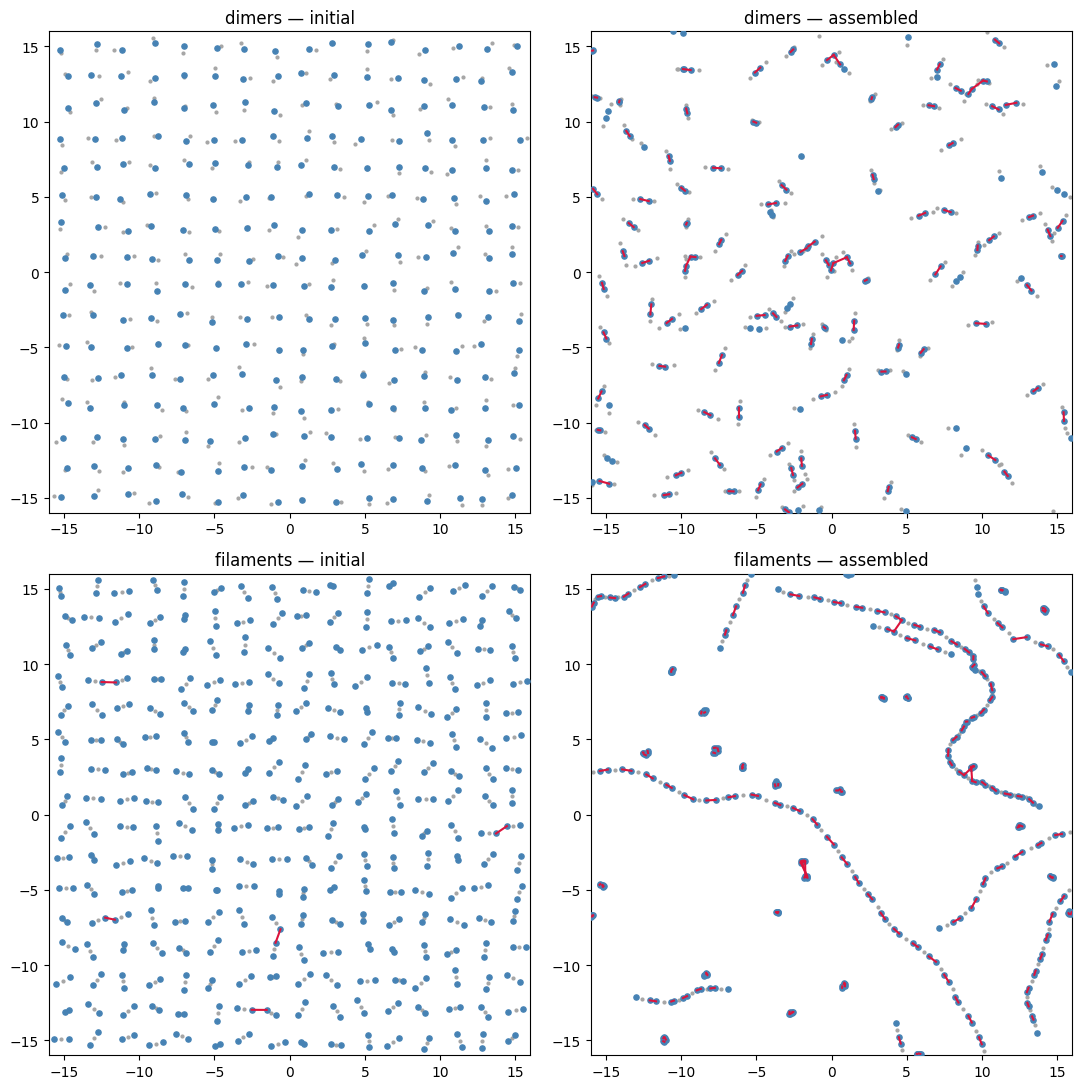

In [5]:
ATT_PER_UNIT = {"dimers": 1, "filaments": 2}   # attractor P particles per unit


def load(kind, tag):
    fr = gsd.hoomd.open(name=str(gsd_path(kind, tag)))[-1 if tag == "traj" else 0]
    return np.asarray(fr.particles.position), np.asarray(fr.particles.typeid)


def contacts(pos_P, box, apu):
    # inter-unit P-P contacts within CONTACT: PBC in x,y (tree), true 3D distance,
    # no wrap in the thin z slab; drop same-unit pairs (unit = P_index // apu)
    xy = (pos_P[:, :2] + box / 2) % box
    pr = cKDTree(xy, boxsize=box).query_pairs(r=CONTACT, output_type="ndarray")
    d = pos_P[pr[:, 0]] - pos_P[pr[:, 1]]
    d[:, :2] -= box * np.round(d[:, :2] / box)
    keep = (np.linalg.norm(d, axis=1) < CONTACT) & ((pr[:, 0] // apu) != (pr[:, 1] // apu))
    return pr[keep]


def draw(ax, kind, tag, box, zoom=16.0):
    pos, tid = load(kind, tag)
    P, D = pos[tid == 0], pos[tid == 1]
    inz = lambda a: (np.abs(a[:, 0]) < zoom) & (np.abs(a[:, 1]) < zoom)
    ax.scatter(D[inz(D), 0], D[inz(D), 1], s=4, c="0.65", zorder=2)
    ax.scatter(P[inz(P), 0], P[inz(P), 1], s=14, c="steelblue", zorder=3)
    for i, j in contacts(P, box, ATT_PER_UNIT[kind]):
        seg = P[[i, j]]
        if np.all(np.abs(seg[:, :2]) < zoom) and np.abs(seg[0, 0] - seg[1, 0]) < zoom:
            ax.plot(seg[:, 0], seg[:, 1], "-", color="crimson", lw=1.5, zorder=4)
    ax.set_xlim(-zoom, zoom); ax.set_ylim(-zoom, zoom); ax.set_aspect("equal")
    ax.set_title(f"{kind} — {'assembled' if tag == 'traj' else 'initial'}")


fig, axes = plt.subplots(2, 2, figsize=(11, 11))
for row, kind in enumerate(WIDTH):
    draw(axes[row, 0], kind, "init", BOX[kind])
    draw(axes[row, 1], kind, "traj", BOX[kind])
fig.tight_layout(); plt.show()

## 5. Structure analysis

Cluster the attractors by their inter-unit contacts (connected components over
units). The valency of the unit sets the outcome: **one patch caps clusters at 2**
(dimers), while **two patches** let the units link end-to-end into a single large
associated network.

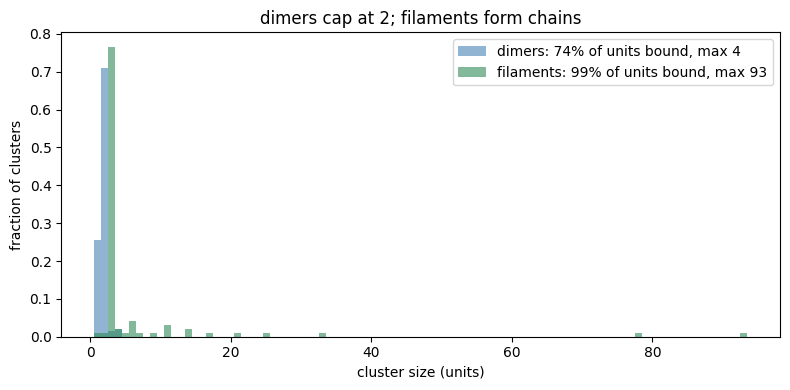

dimers: max cluster 4 (should be ~2)   filaments: max cluster 93


In [6]:
def cluster_sizes(kind):
    apu = ATT_PER_UNIT[kind]
    pos, tid = load(kind, "traj")
    P = pos[tid == 0]
    n_units = P.shape[0] // apu
    adj = {i: set() for i in range(n_units)}
    for i, j in contacts(P, BOX[kind], apu):
        a, b = int(i // apu), int(j // apu)
        adj[a].add(b); adj[b].add(a)
    seen, sizes = set(), []
    for s in range(n_units):
        if s in seen:
            continue
        stack, comp = [s], 0
        while stack:
            u = stack.pop()
            if u in seen:
                continue
            seen.add(u); comp += 1
            stack.extend(adj[u] - seen)
        sizes.append(comp)
    return np.array(sizes)


fig, ax = plt.subplots(figsize=(8, 4))
for kind, color in [("dimers", "steelblue"), ("filaments", "seagreen")]:
    s = cluster_sizes(kind)
    bound = (s >= 2).mean()
    ax.hist(s, bins=np.arange(1, max(6, s.max()) + 2) - 0.5, density=True, alpha=0.6,
            color=color, label=f"{kind}: {bound:.0%} of units bound, max {s.max()}")
ax.set_xlabel("cluster size (units)"); ax.set_ylabel("fraction of clusters")
ax.set_title("dimers cap at 2; filaments form chains"); ax.legend()
fig.tight_layout(); plt.show()

dz = cluster_sizes("dimers"); fl = cluster_sizes("filaments")
print(f"dimers: max cluster {dz.max()} (should be ~2)   filaments: max cluster {fl.max()}")
assert fl.max() > dz.max(), "filaments should form larger clusters than dimers"


## What to try next

- **Dilute the filaments:** at lower density the 2-patch chains form *separate*
  finite strands instead of one condensed network — self-assembly kinetics vs the
  associating-polymer phase transition.
- **Patch width** `width`: widen it and even dimers make promiscuous multi-contacts
  (branching); narrow it for cleaner, more directional bonding.
- **Strength vs temperature:** lower `EPSILON` (or raise `kT`) below the assembly
  threshold and the structures melt back into a gas.